## Xử lý cho cả 2 mô hình trước khi train

### Import libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

pd.set_option('display.max_columns', None) # hiện thị đầy đủ các cột khi in df

### Load Dataset

In [4]:
# Load dataset đã được clean sẵn của hãng DL (Delter Airlines)
df = pd.read_csv("../data/processed/flights_DL.csv")

C:\Users\Phong\AppData\Local\Temp\ipykernel_20784\2877665700.py:2: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/flights_DL.csv")


### Kiểm tra lại để đảm bảo chỉ còn đúng hãng DL

In [5]:
print(df['AIRLINE'].unique())
print(df['AIRLINE'].nunique()) # ki vong la 1

# Vì chỉ có 1 hãng nên loại bỏ cột AIRLINE luôn
df = df.drop(columns=['AIRLINE'])

['DL']
1


### Explore Dataset

In [6]:
# check tổng quan kiểu dũ liệu và số lượng giá trị null của từng cột
df.info()

# Kiểm tra số chuyến bay bị hủy (CANCELLED) và bị chuyển hướng (DIVERTED) và vì các chuyến này không có ARRIVAL_DELAY nên loại luôn
print(df['CANCELLED'].value_counts())
print(df['DIVERTED'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 875881 entries, 0 to 875880
Data columns (total 36 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   YEAR                  875881 non-null  int64  
 1   MONTH                 875881 non-null  int64  
 2   DAY                   875881 non-null  int64  
 3   DAY_OF_WEEK           875881 non-null  int64  
 4   FLIGHT_NUMBER         875881 non-null  int64  
 5   TAIL_NUMBER           875881 non-null  object 
 6   ORIGIN_AIRPORT        875881 non-null  object 
 7   DESTINATION_AIRPORT   875881 non-null  object 
 8   SCHEDULED_DEPARTURE   875881 non-null  int64  
 9   DEPARTURE_TIME        872177 non-null  float64
 10  DEPARTURE_DELAY       872177 non-null  float64
 11  TAXI_OUT              872094 non-null  float64
 12  WHEELS_OFF            872094 non-null  float64
 13  SCHEDULED_TIME        875881 non-null  float64
 14  ELAPSED_TIME          870275 non-null  float64
 15  

### Kiểm tra biến target

In [7]:
# Loại chuyến bay bị hủy hoặc chuyển hướng
df = df[(df['CANCELLED'] == 0) & (df['DIVERTED'] == 0)].reset_index(drop=True)
# biến target đã có sẵn nên không tạo nữa
#check tỉ lệ phân bố target
print(df['IS_DELAYED'].value_counts(normalize=True))

IS_DELAYED
0.0    0.864384
1.0    0.135616
Name: proportion, dtype: float64


### Xử lí đặc trưng

In [10]:
# SCHEDULED_DEPARTURE có dạng số nguyên kiểu "1730" nghĩa là 17 giờ 30 phút
# tách thành 2 cột riêng: giờ và phút, để model dễ học pattern theo khung giờ

def extract_hour(x):
    return int(x) // 100   # lấy phần nguyên hàng trăm/nghìn = giờ

def extract_minute(x):
    return int(x) % 100    # lấy phần dư = phút

df['scheduled_hour'] = df['SCHEDULED_DEPARTURE'].apply(extract_hour)
df['scheduled_minute'] = df['SCHEDULED_DEPARTURE'].apply(extract_minute)

# Tạo ROUTE = cặp sân bay đi - đến, giúp model học đặc thù riêng của từng tuyến bay
df['ROUTE'] = df['ORIGIN_AIRPORT_CLEAN'] + '_' + df['DEST_AIRPORT_CLEAN']

### Chọn đặc trưng

In [12]:
# Chọn các feature được phép dùng (biết trước giờ bay, không gây leakage)
feature_cols = [
    'MONTH', 'DAY', 'DAY_OF_WEEK',
    'ORIGIN_AIRPORT_CLEAN', 'DEST_AIRPORT_CLEAN', 'ROUTE',
    'DISTANCE', 'scheduled_hour', 'scheduled_minute'
]
target_col = 'IS_DELAYED'

# Tạo DataFrame chỉ gồm feature + target, dùng cho các bước tiếp theo
model_df = df[feature_cols + [target_col]].copy()
model_df.head()

,MONTH,DAY,DAY_OF_WEEK,ORIGIN_AIRPORT_CLEAN,DEST_AIRPORT_CLEAN,ROUTE,DISTANCE,scheduled_hour,scheduled_minute,IS_DELAYED
0,1,1,4,SFO,MSP,SFO_MSP,1589,0,25,0.0
1,1,1,4,LAS,ATL,LAS_ATL,1747,0,30,0.0
2,1,1,4,DEN,ATL,DEN_ATL,1199,0,30,0.0
3,1,1,4,LAX,MSP,LAX_MSP,1535,0,35,0.0
4,1,1,4,SLC,ATL,SLC_ATL,1590,0,40,0.0


### Chia tập test/set

In [14]:
# Sắp xếp dữ liệu theo thời gian trước khi chia train/test vì đây là time-based split, không phải random split)
model_df = model_df.sort_values(['MONTH', 'DAY']).reset_index(drop=True)

# Train: 9 tháng đầu năm | Test: 3 tháng cuối năm
# Mô phỏng đúng tình huống thực tế: model chỉ học từ quá khứ, dự đoán cho tương lai
train_df = model_df[model_df['MONTH'] <= 9].reset_index(drop=True)
test_df  = model_df[model_df['MONTH'] > 9].reset_index(drop=True)

print(f"Train: {train_df.shape[0]} | Test: {test_df.shape[0]}")
print(f"Tỷ lệ trễ train: {train_df['IS_DELAYED'].mean():.3f} | test: {test_df['IS_DELAYED'].mean():.3f}")

Train: 652391 | Test: 217884
Tỷ lệ trễ train: 0.143 | test: 0.113


### Hàm gộp rare categories

In [15]:
# Hàm gộp các category ít xuất hiện thành nhóm "OTHER"
# Mục đích: tránh one-hot encoding sinh ra quá nhiều cột (vì sân bay/route rất nhiều)
def group_rare_categories(train_series, test_series, top_n=15):
    # Chỉ lấy top_n giá trị phổ biến nhất từ tập train, chống leakage, không để thông tin từ test ảnh hưởng đến quyết định này)
    top_values = train_series.value_counts().nlargest(top_n).index

    # Áp dụng cùng danh sách top_values cho cả train và test
    train_new = train_series.where(train_series.isin(top_values), other='OTHER')
    test_new = test_series.where(test_series.isin(top_values), other='OTHER')
    return train_new, test_new

### Áp dụng gộp rare categories

In [17]:
# Áp dụng gộp rare category cho từng cột categorical nhiều giá trị
train_df['ORIGIN_AIRPORT_CLEAN'], test_df['ORIGIN_AIRPORT_CLEAN'] = group_rare_categories(
    train_df['ORIGIN_AIRPORT_CLEAN'], test_df['ORIGIN_AIRPORT_CLEAN'], top_n=15)

train_df['DEST_AIRPORT_CLEAN'], test_df['DEST_AIRPORT_CLEAN'] = group_rare_categories(
    train_df['DEST_AIRPORT_CLEAN'], test_df['DEST_AIRPORT_CLEAN'], top_n=15)

train_df['ROUTE'], test_df['ROUTE'] = group_rare_categories(
    train_df['ROUTE'], test_df['ROUTE'], top_n=30)

### One-hot encoding + align train/test

In [20]:
# One-hot encoding cho các biến categorical
categorical_cols = ['ORIGIN_AIRPORT_CLEAN', 'DEST_AIRPORT_CLEAN', 'ROUTE', 'DAY_OF_WEEK', 'MONTH']

train_encoded = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)
test_encoded = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)

# Đảm bảo train và test có cùng số cột sau one-hot
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

# Tách riêng feature (X) và target (y)
X_train = train_encoded.drop(columns=['IS_DELAYED'])
y_train = train_encoded['IS_DELAYED']
X_test = test_encoded.drop(columns=['IS_DELAYED'])
y_test = test_encoded['IS_DELAYED']

print(f"Số feature sau encoding: {X_train.shape[1]}")

Số feature sau encoding: 77


## Logistic Regression

### Scaling cho Logistic Regression

In [21]:
from sklearn.preprocessing import StandardScaler

# Logistic Regression nhạy cảm với thang đo nên cần chuẩn hóa các cột số
numeric_cols = ['DISTANCE', 'scheduled_hour', 'scheduled_minute', 'DAY']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# fit scaler CHỈ trên train, transform cho cả train và test không fit trên test để tránh làm lộ thông tin phân phối của tập test
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

### Train Logistic Regression baseline

In [22]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression: tính tổ hợp tuyến tính của feature, qua hàm sigmoid
# ra xác suất trễ từ 0 đến 1. Dùng làm baseline vì đơn giản
log_reg = LogisticRegression(
    max_iter=1000,           # tăng số vòng lặp để đảm bảo hội tụ
    class_weight='balanced', # xử lý mất cân bằng lớp (DELAYED=1 là thiểu số)
    random_state=42          # cố định seed để tái lập kết quả
)
log_reg.fit(X_train_scaled, y_train)

# Dự đoán nhãn 0/1 và xác suất trễ
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Đã train xong Logistic Regression baseline.")

Đã train xong Logistic Regression baseline.


### Logistic Regression Predict

In [25]:
# Dự đoán nhãn 0/1 (có trễ hay không) trên tập test
y_pred_log = log_reg.predict(X_test_scaled)

# Dự đoán xác suất trễ (cột index 1 = xác suất của lớp DELAYED=1)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Đã dự đoán xong trên tập test.")

Đã dự đoán xong trên tập test.


## Random Forest

### Train Model Random Forest

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,        # số lượng cây trong rừng; nhiều cây hơn -> ổn định hơn nhưng chậm hơn
    max_depth=10,            # giới hạn độ sâu mỗi cây để tránh overfitting
    class_weight='balanced', # xử lý mất cân bằng lớp, giống Logistic Regression
    random_state=42,         # cố định seed để kết quả tái lập được
    n_jobs=-1                # dùng toàn bộ CPU core có sẵn để train nhanh hơn
)

# Random Forest KHÔNG cần scaling dữ liệu (khác với Logistic Regression),
# vì cây quyết định chia dữ liệu dựa trên ngưỡng (threshold) chứ không quan tâm thang đo
rf_model.fit(X_train, y_train)

print("Đã train xong Random Forest.")

Đã train xong Random Forest.


### Predict Random Forest

In [24]:
# Dự đoán nhãn 0/1 (có trễ hay không) trên tập test
y_pred_rf = rf_model.predict(X_test)

# Dự đoán xác suất trễ (cột index 1 = xác suất của lớp DELAYED=1)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Đã dự đoán xong trên tập test.")

Đã dự đoán xong trên tập test.


## Đánh giá và so sánh

### Evalution Metric

In [26]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

def evaluate_model(y_true, y_pred, y_prob, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_prob)
    }

metrics_log = evaluate_model(y_test, y_pred_log, y_prob_log, 'Logistic Regression')
metrics_rf = evaluate_model(y_test, y_pred_rf, y_prob_rf, 'Random Forest')

results_df = pd.DataFrame([metrics_log, metrics_rf])
print(results_df.round(3))

                 Model  Accuracy  Precision  Recall     F1  ROC-AUC
0  Logistic Regression     0.645      0.143   0.428  0.214    0.567
1        Random Forest     0.598      0.143   0.508  0.223    0.576


### Confusion Matrix

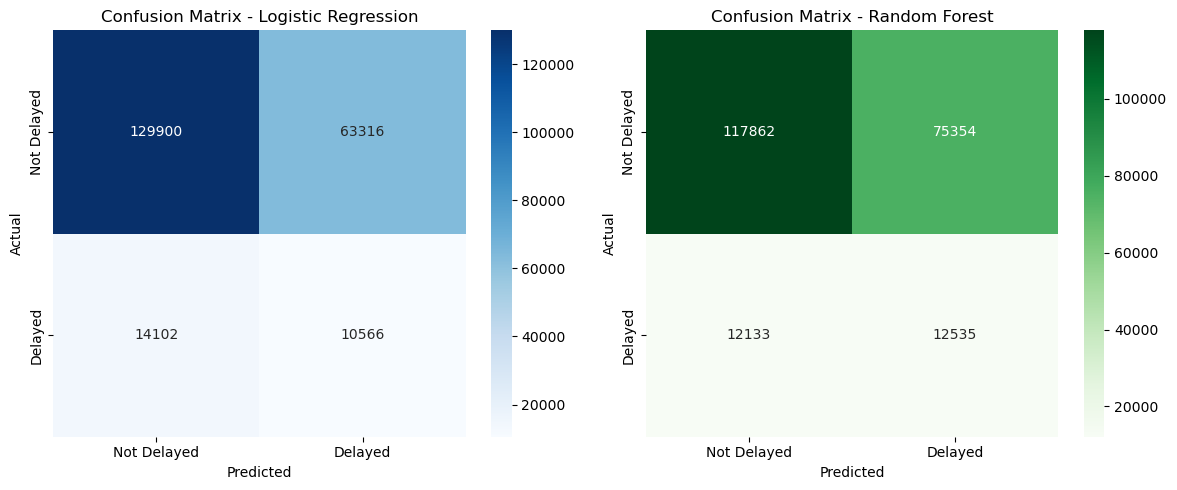

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_log = confusion_matrix(y_test, y_pred_log)
sb.heatmap(cm_log, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Delayed', 'Delayed'],
            yticklabels=['Not Delayed', 'Delayed'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sb.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Delayed', 'Delayed'],
            yticklabels=['Not Delayed', 'Delayed'], ax=axes[1])
axes[1].set_title('Confusion Matrix - Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### ROC Curve

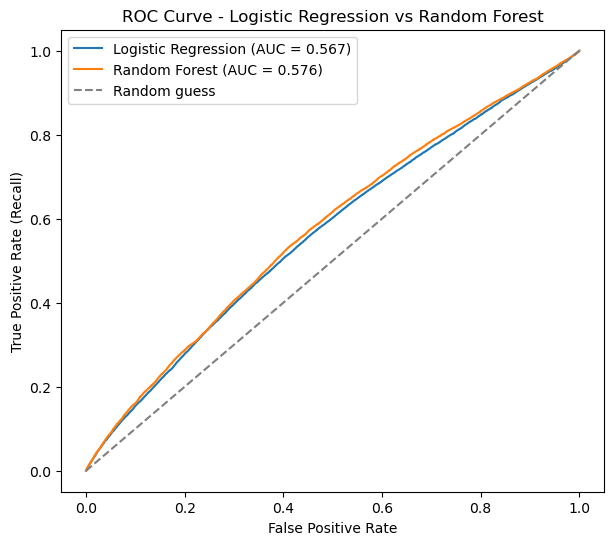

In [28]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {metrics_log["ROC-AUC"]:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {metrics_rf["ROC-AUC"]:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')

plt.title('ROC Curve - Logistic Regression vs Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.show()

### Important Feature cuả Random Forest

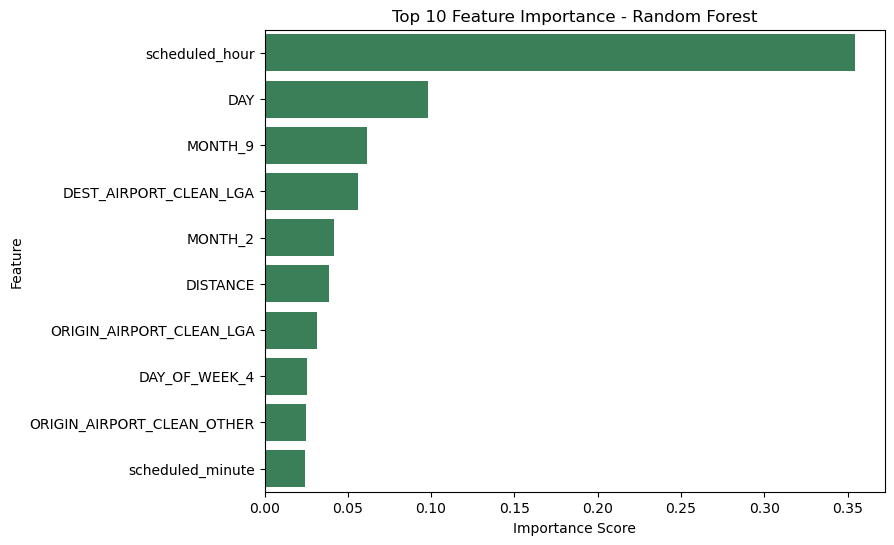

scheduled_hour                0.354501
DAY                           0.098049
MONTH_9                       0.061673
DEST_AIRPORT_CLEAN_LGA        0.055867
MONTH_2                       0.041774
DISTANCE                      0.038528
ORIGIN_AIRPORT_CLEAN_LGA      0.031462
DAY_OF_WEEK_4                 0.025227
ORIGIN_AIRPORT_CLEAN_OTHER    0.025050
scheduled_minute              0.024314
dtype: float64


In [30]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
sb.barplot(x=top10.values, y=top10.index, color='seagreen')
plt.title('Top 10 Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

print(top10)

### Xác suất dự đoán trễ

In [32]:
# Dùng model tốt hơn (dựa trên bảng so sánh ở Cell 16) để xếp hạng rủi ro thực tế
# Giả sử Random Forest tốt hơn -> dùng y_prob_rf (đổi lại nếu LR tốt hơn)

results = test_df.copy()
results['Delay_Probability'] = y_prob_rf

results_sorted = results.sort_values('Delay_Probability', ascending=False)
print(results_sorted[['ROUTE', 'MONTH', 'DAY', 'scheduled_hour', 'Delay_Probability']].head(10))

        ROUTE  MONTH  DAY  scheduled_hour  Delay_Probability
166079  OTHER     12    8              19           0.747768
99891   OTHER     11   10              19           0.747214
165818  OTHER     12    8              17           0.746582
99619   OTHER     11   10              17           0.746029
117266  OTHER     11   17              19           0.745302
182456  OTHER     12   15              19           0.744861
82572   OTHER     11    3              19           0.744430
122437  OTHER     11   19              19           0.744071
116991  OTHER     11   17              17           0.744025
182196  OTHER     12   15              17           0.743584


### Xác đính flights có rủi ro cao

In [38]:
high_risk_flights = results[results['Delay_Probability'] >= 0.7]

print(f"Số chuyến nguy cơ cao: {len(high_risk_flights)}")
print(f"Tỷ lệ trên tổng số chuyến test: {len(high_risk_flights) / len(results):.2%}")

Số chuyến nguy cơ cao: 114
Tỷ lệ trên tổng số chuyến test: 0.05%


### Phân tích routes có rủi ro cao

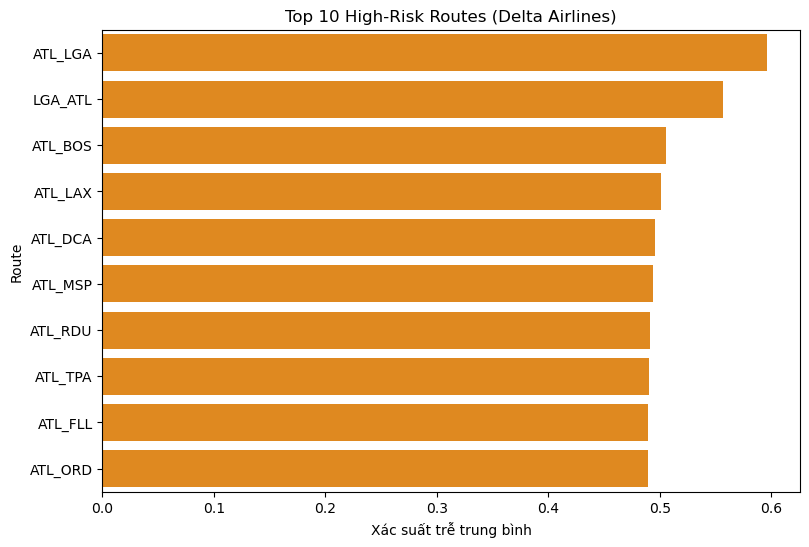

      ROUTE  avg_delay_probability  num_flights
8   ATL_LGA               0.595733          965
23  LGA_ATL               0.556396          968
0   ATL_BOS               0.505024          641
7   ATL_LAX               0.500676          650
3   ATL_DCA               0.495878          806
11  ATL_MSP               0.493936          644
14  ATL_RDU               0.491158          701
15  ATL_TPA               0.489983          847
5   ATL_FLL               0.489342          859
13  ATL_ORD               0.489226          637


In [35]:
route_risk = results.groupby('ROUTE').agg(
    avg_delay_probability=('Delay_Probability', 'mean'),
    num_flights=('Delay_Probability', 'count')
).reset_index()

route_risk = route_risk[route_risk['num_flights'] >= 5]
top10_routes = route_risk.sort_values('avg_delay_probability', ascending=False).head(10)

plt.figure(figsize=(9, 6))
sb.barplot(x='avg_delay_probability', y='ROUTE', data=top10_routes, color='darkorange')
plt.title('Top 10 High-Risk Routes (Delta Airlines)')
plt.xlabel('Xác suất trễ trung bình')
plt.ylabel('Route')
plt.show()

print(top10_routes)

### Phân tích rủi ro cao theo Departure Hour

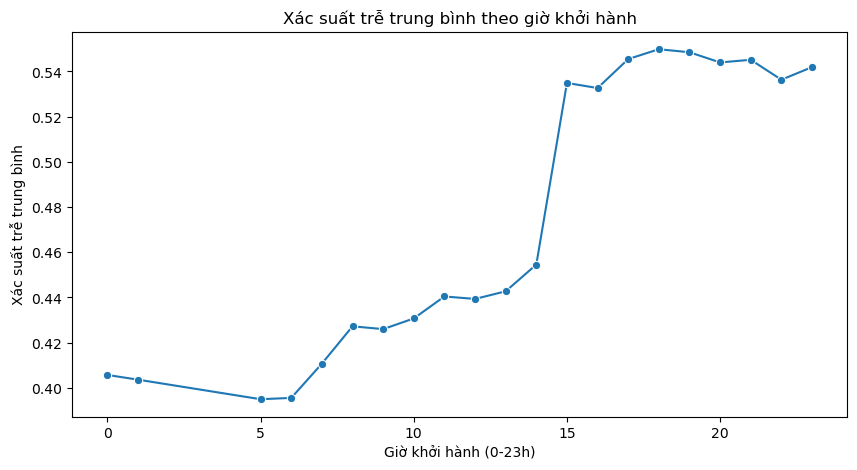

    scheduled_hour  Delay_Probability
0                0           0.405710
1                1           0.403623
2                5           0.394977
3                6           0.395561
4                7           0.410712
5                8           0.427233
6                9           0.425989
7               10           0.430708
8               11           0.440430
9               12           0.439341
10              13           0.442717
11              14           0.454535
12              15           0.534895
13              16           0.532625
14              17           0.545451
15              18           0.549806
16              19           0.548458
17              20           0.543957
18              21           0.545132
19              22           0.536310
20              23           0.541888


In [37]:
hour_risk = results.groupby('scheduled_hour')['Delay_Probability'].mean().reset_index()

plt.figure(figsize=(10, 5))
sb.lineplot(x='scheduled_hour', y='Delay_Probability', data=hour_risk, marker='o')
plt.title('Xác suất trễ trung bình theo giờ khởi hành')
plt.xlabel('Giờ khởi hành (0-23h)')
plt.ylabel('Xác suất trễ trung bình')
plt.show()

print(hour_risk)

### Business inside và kết luận

In [47]:
print("TÓM TẮT KẾT QUẢ MODEL")
print("-" * 60)
print(results_df.round(3))

print("\n" + "-" * 60)
print("SỐ CHUYẾN NGUY CƠ CAO (probability >= 0.7)")
print("-" * 60)
print(f"Số chuyến: {len(high_risk_flights)} / {len(results)} chuyến test")
print(f"Tỷ lệ: {len(high_risk_flights) / len(results):.2%}")

TÓM TẮT KẾT QUẢ MODEL
------------------------------------------------------------
                 Model  Accuracy  Precision  Recall     F1  ROC-AUC
0  Logistic Regression     0.645      0.143   0.428  0.214    0.567
1        Random Forest     0.598      0.143   0.508  0.223    0.576

------------------------------------------------------------
SỐ CHUYẾN NGUY CƠ CAO (probability >= 0.7)
------------------------------------------------------------
Số chuyến: 114 / 217884 chuyến test
Tỷ lệ: 0.05%
